In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style setup
plt.style.use('ggplot')
%matplotlib inline

In [14]:
# Load raw hourly energy data
df = pd.read_csv('../data/raw/AEP_hourly.csv')

In [15]:
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [16]:
# Convert timestamp column to datetime & set as index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

# Display standard info
print(df.info())
df.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 121273 entries, 2004-10-01 01:00:00 to 2018-08-03 00:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   AEP_MW  121273 non-null  float64
dtypes: float64(1)
memory usage: 1.9 MB
None


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


Missing Values: 0
Duplicate Timestamps: 4


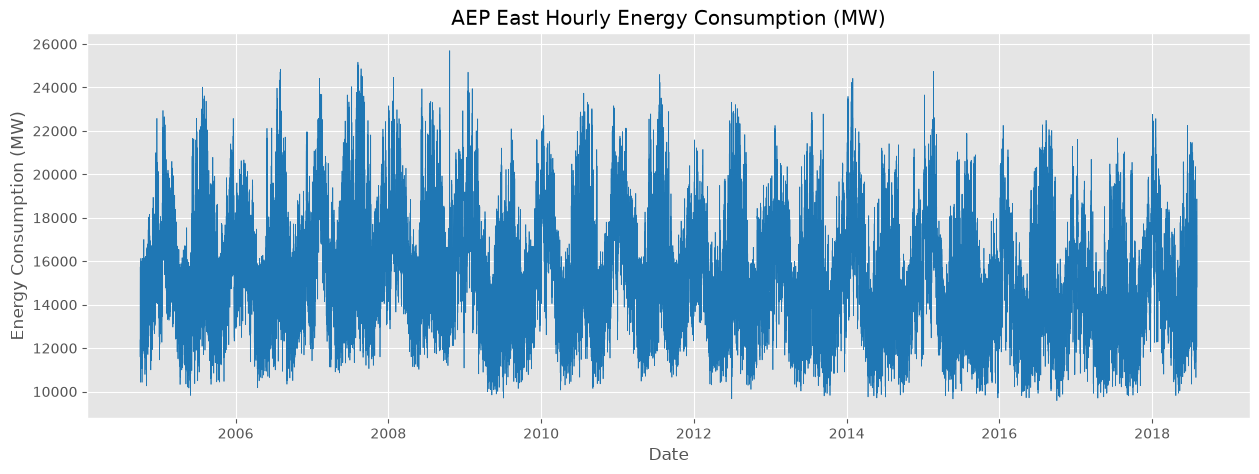

In [5]:
# Check for null values or duplicated timestamps
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Timestamps:", df.index.duplicated().sum())

# Basic Time Series Plot
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['AEP_MW'], color='tab:blue', linewidth=0.5)
plt.title('AEP East Hourly Energy Consumption (MW)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (MW)')
plt.show()

In [ ]:
# 1. Remove duplicate timestamps by taking the average value for duplicates
df = df.groupby(df.index).mean()

# 2. Resample to ensure a continuous hourly frequency ('h')
# If any hours are missing, this creates rows with NaN values for those timestamps
full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
df = df.reindex(full_idx)

# 3. Interpolate any missing values introduced by missing hours
missing_before = df['AEP_MW'].isnull().sum()
df['AEP_MW'] = df['AEP_MW'].interpolate(method='linear')

print(f"Fixed missing hours: {missing_before} gaps interpolated.")
print(f"Any remaining nulls? {df.isnull().sum().sum()}")

Fixed missing hours: 27 gaps interpolated.
Any remaining nulls? 0


In [21]:
# Add time-based features
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['quarter'] = df.index.quarter
df['month'] = df.index.month
df['year'] = df.index.year
df['dayofyear'] = df.index.dayofyear

# Inspect the feature dataframe
df.head(10)

,AEP_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
2004-10-01 01:00:00,12379.0,1,4,4,10,2004,275
2004-10-01 02:00:00,11935.0,2,4,4,10,2004,275
2004-10-01 03:00:00,11692.0,3,4,4,10,2004,275
2004-10-01 04:00:00,11597.0,4,4,4,10,2004,275
2004-10-01 05:00:00,11681.0,5,4,4,10,2004,275
2004-10-01 06:00:00,12280.0,6,4,4,10,2004,275
2004-10-01 07:00:00,13692.0,7,4,4,10,2004,275
2004-10-01 08:00:00,14618.0,8,4,4,10,2004,275
2004-10-01 09:00:00,14903.0,9,4,4,10,2004,275


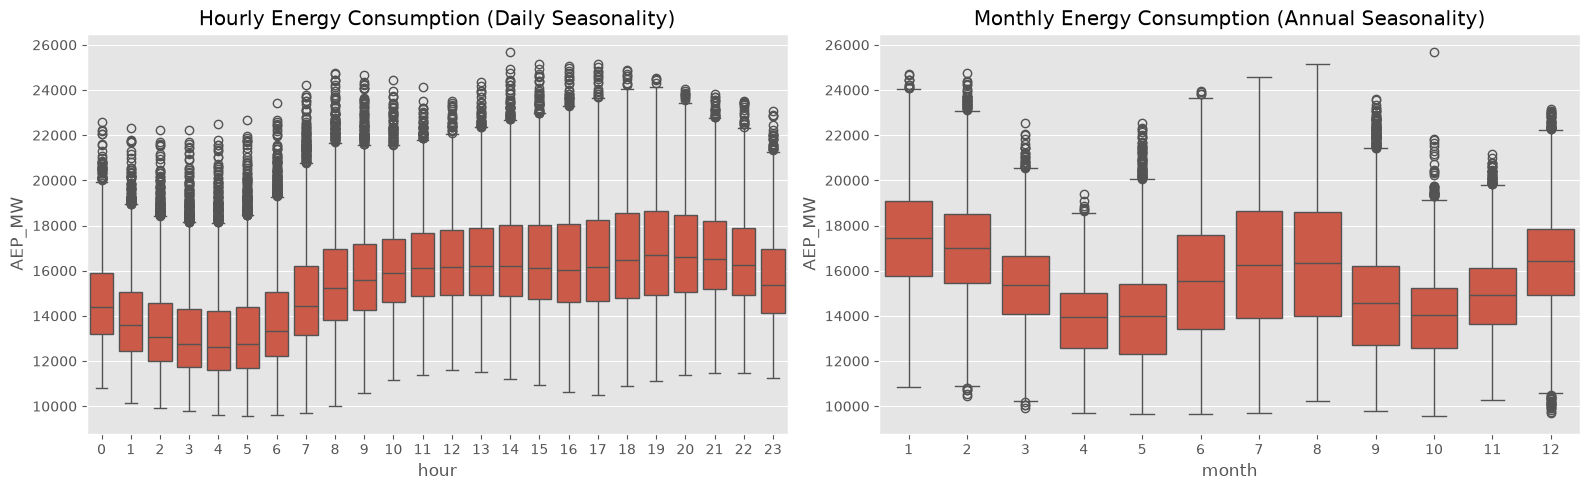

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x='hour', y='AEP_MW', ax=ax[0])
ax[0].set_title('Hourly Energy Consumption (Daily Seasonality)')

sns.boxplot(data=df, x='month', y='AEP_MW', ax=ax[1])
ax[1].set_title('Monthly Energy Consumption (Annual Seasonality)')

plt.tight_layout()
plt.show()

In [23]:
import os

os.makedirs("../data/processed", exist_ok=True)

processed_path = "../data/processed/processed_aep.csv"

df.to_csv(processed_path, index = True)

print(f"Successfully saved clean dataset to: {processed_path}")
print(f"Dataset shape: {df.shape}")

Successfully saved clean dataset to: ../data/processed/processed_aep.csv
Dataset shape: (121273, 7)
